# Seaborn 

## Why Seaborn?
### - provides a layer of abstraction hence simpler to use
### - better aesthetics
### - more graphs included

## Seaborn Roadmap

### - Types of Functions

### - Figure Level
### - Axis Level    
                           
##### - Main Classification

##### - Relational Plot
##### - Distribution Plot
##### - Categorical Plot
##### - Regression Plot
##### - Matrix Plot
##### - Multiplots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy # for clustermap

## 1. Relational Plot
### - to see the statistical relation between 2 or more variables.
### - Bivariate Analysis
### - Plots under this section

### - scatterplot
### - lineplot

In [2]:
# importing data set

# tips data set
tips = pd.read_csv('data/tips.csv')

# gapminder data set
gap = pd.read_csv('data/gapminder.csv')

# titanic data set
titanic = pd.read_csv('data/titanic.csv')

# iris data set
iris = pd.read_csv('data/iris.csv')

<Axes: xlabel='total_bill', ylabel='tip'>

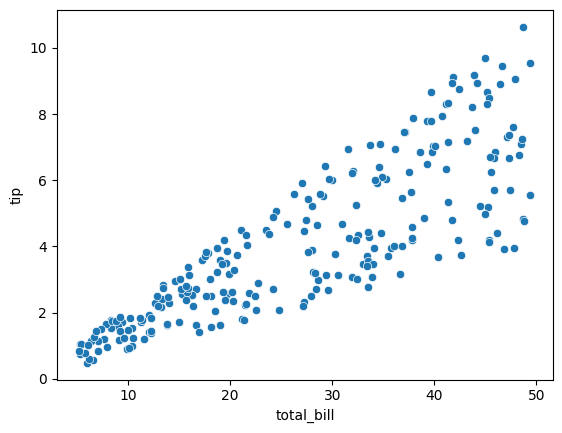

In [3]:
# scatter plot -> axes level function
sns.scatterplot(data=tips,x='total_bill',y='tip')

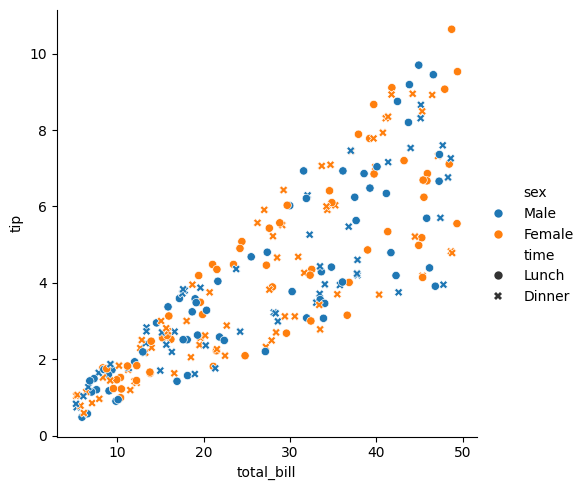

In [4]:
# figure level function

# relplot plot -> fig level function
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',hue='sex',style='time')

<Axes: xlabel='total_bill', ylabel='tip'>

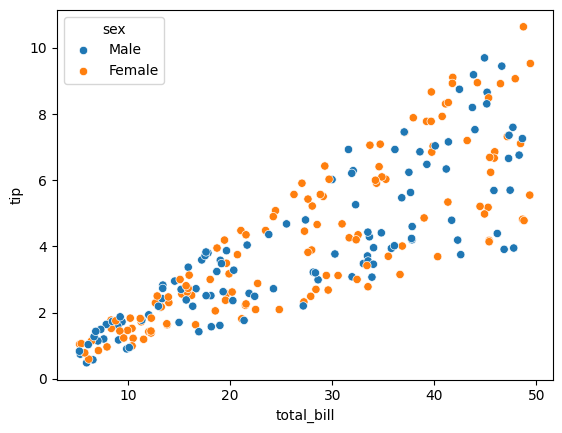

In [5]:
# hue parameter
# scatter plot -> axes level function
sns.scatterplot(data=tips,x='total_bill',y='tip', hue='sex')

<Axes: xlabel='total_bill', ylabel='tip'>

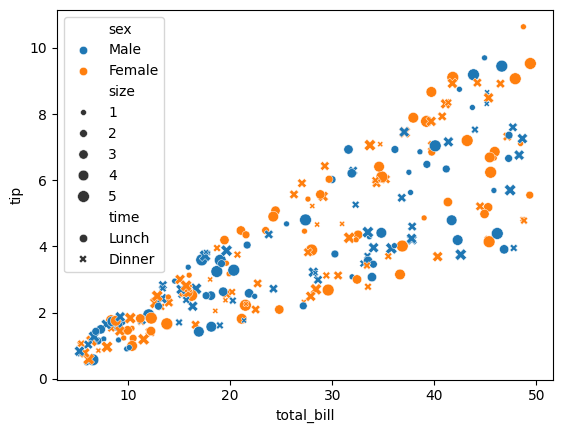

In [6]:
# style parameter
# scatter plot -> axes level function
sns.scatterplot(data=tips,x='total_bill',y='tip', hue='sex',style='time',size='size')

#### Line plot

<Axes: xlabel='year', ylabel='lifeExp'>

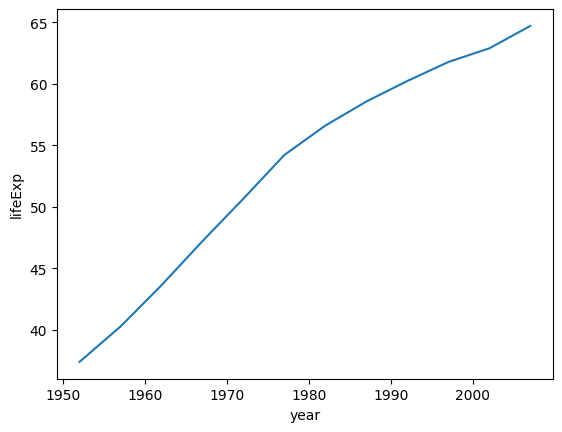

In [7]:
# line plot -> to show continuity


# plot graph of india's lifeExp from from 1952 - 2020


temp_df = gap[gap['country'] == 'India']

# plotting (axes level function)
sns.lineplot(data=temp_df,x='year',y='lifeExp')

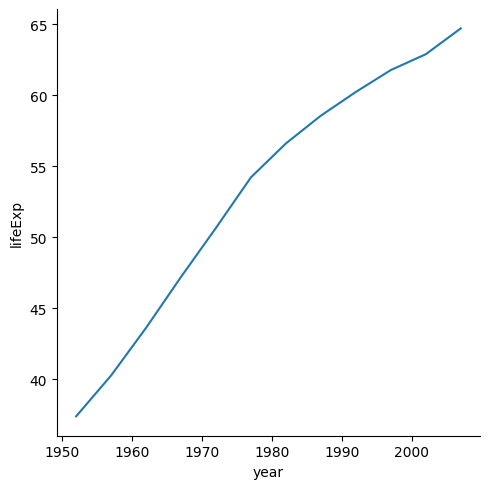

In [8]:
# using relplot
sns.relplot(data=temp_df,x='year',y='lifeExp',kind='line')

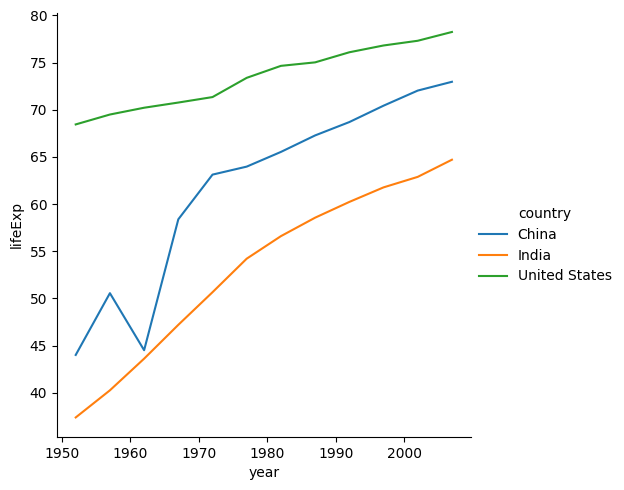

In [9]:
# hue and style parameter 
temp_df = gap[gap['country'].isin(['India','China','United States'])]
sns.relplot(kind='line',data=temp_df,x='year',y='lifeExp',hue='country')

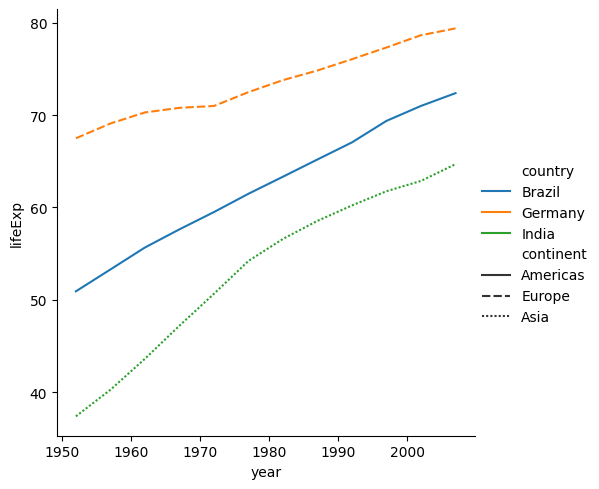

In [10]:
# countries from different continent
temp_df = gap[gap['country'].isin(['India','Brazil','Germany'])]
sns.relplot(kind='line',data=temp_df,x='year',y='lifeExp',hue='country',style='continent')

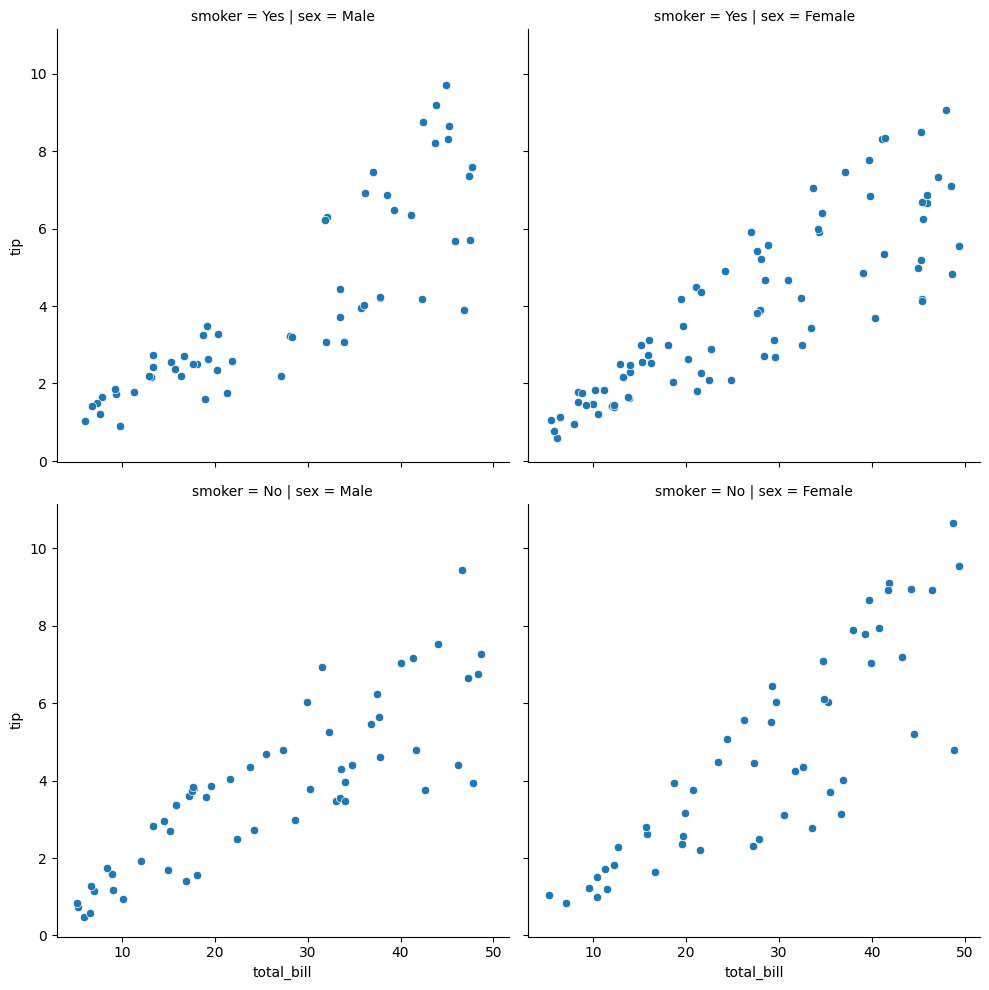

In [11]:
# facet plot -> Facet plots are used to display multiple graphs for different categories of a categorical column
# facet plot -> figure level function -> work with relplot
# it will not work with scatterplot and lineplot
# we'll use col or row parameter
# col for side by side and row for other
sns.relplot(data=tips,x='total_bill',y='tip',row='smoker',col='sex',kind='scatter')

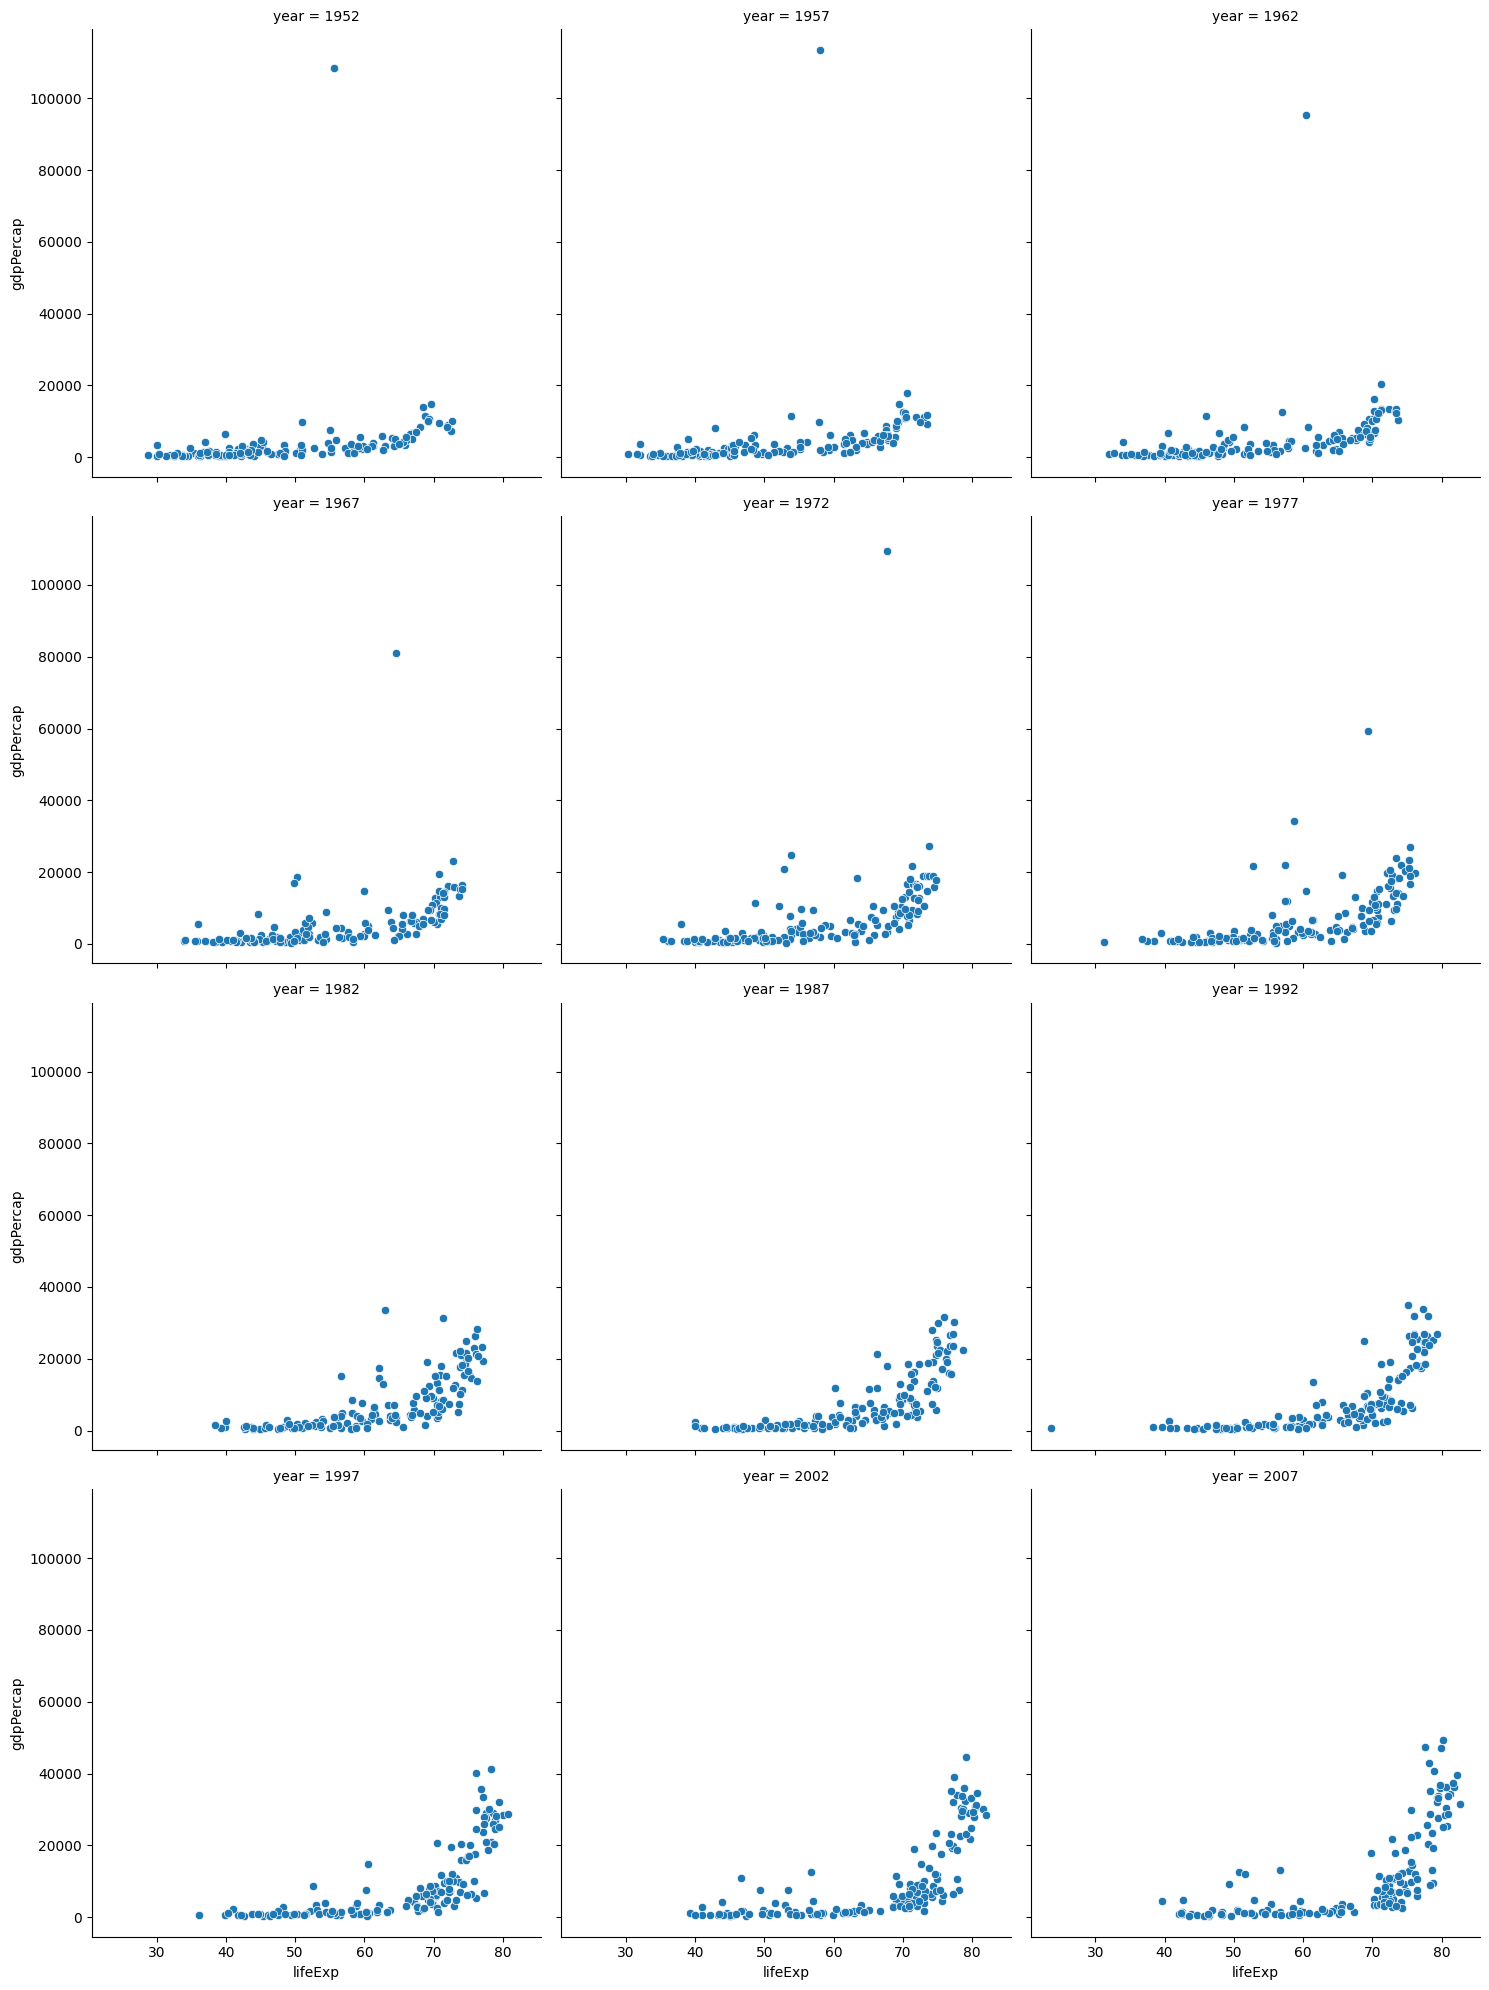

In [12]:
# col wrap
sns.relplot(data=gap, x='lifeExp', y='gdpPercap', kind='scatter', col='year', col_wrap=3)

## 2. Distribution Plots
### - used for univariate analysis
### - used to find out the distribution
### - Range of the observation
### - Central Tendency
### - is the data bimodal?
### - Are there outliers?
### - Plots under distribution plot

#### - histplot
#### - kdeplot
#### - rugplot

In [13]:
# figure level function -> distplot 
# axes level function -> histplot, kdeplot, rugplot

<Axes: xlabel='total_bill', ylabel='Count'>

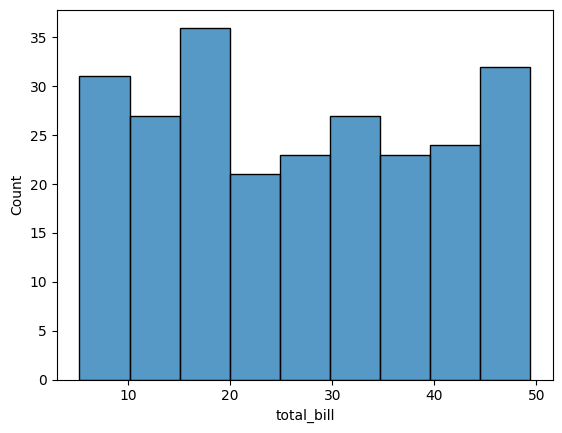

In [14]:
# plotting univariate histogram
sns.histplot(data=tips,x='total_bill')

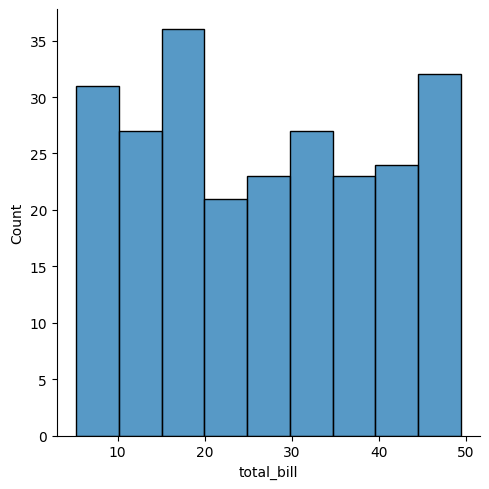

In [15]:
# using distplot
sns.displot(data=tips, x='total_bill',kind='hist')

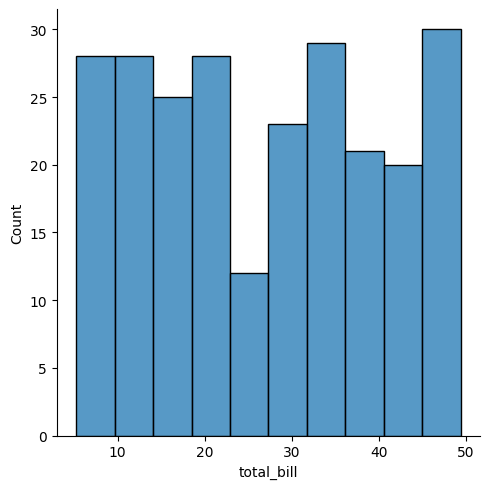

In [16]:
# bins parameter
sns.displot(data=tips, x='total_bill',kind='hist',bins=10)

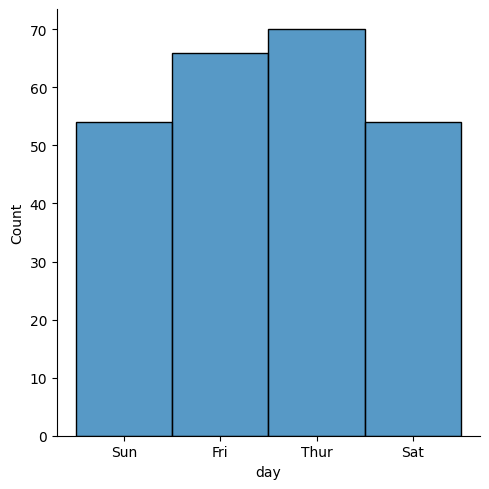

In [17]:
# It’s also possible to visualize the distribution of a categorical variable using the logic of a histogram. 
# Discrete bins are automatically set for categorical variables

# technically as a countplot
sns.displot(data=tips, x='day', kind='hist')

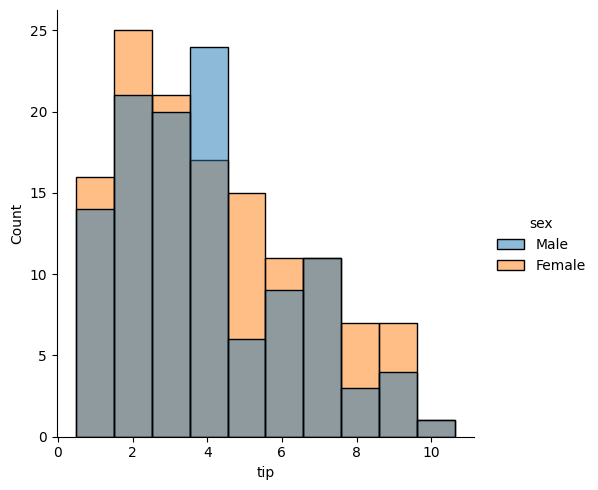

In [18]:
# hue parameter
sns.displot(data=tips, x='tip', kind='hist',hue='sex')

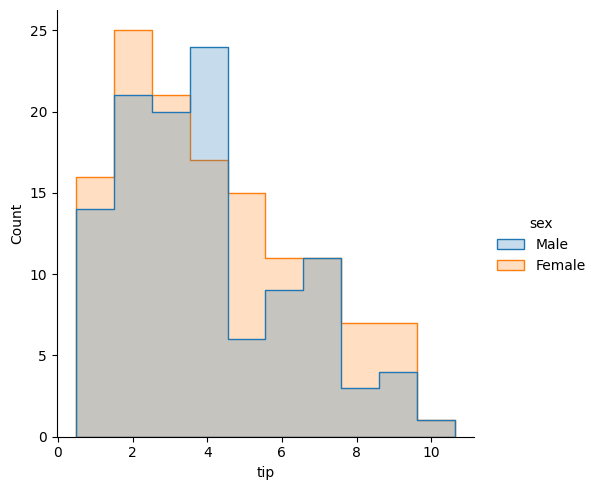

In [19]:
# element=step -> to get a clear picture of the graph
sns.displot(data=tips, x='tip',kind='hist',hue='sex',element='step')

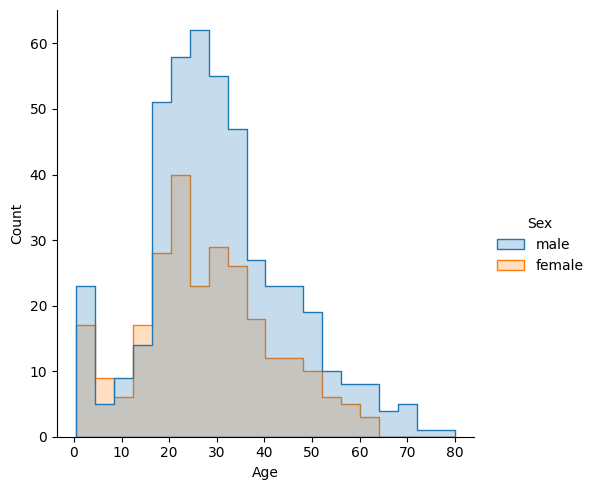

In [20]:
sns.displot(data=titanic, x='Age', kind='hist',element='step',hue='Sex')

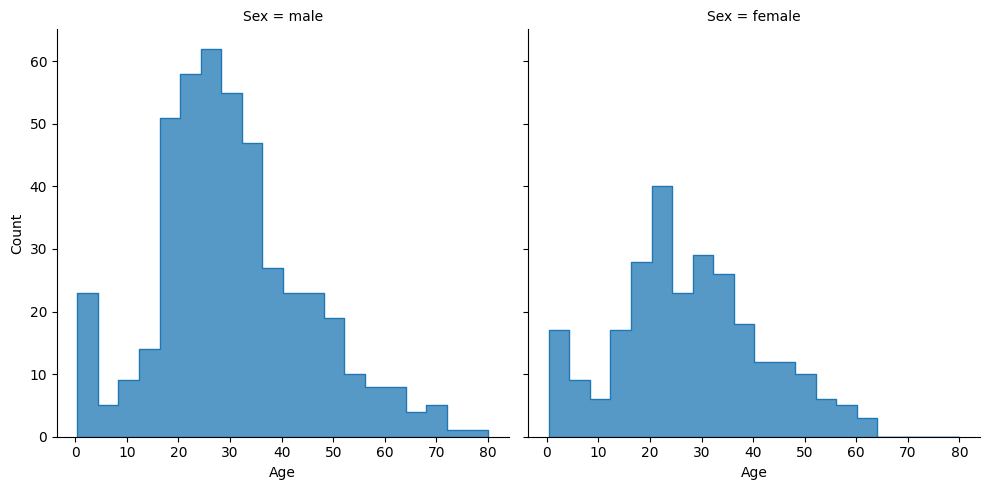

In [21]:
# faceting using col and rows -> this will not work on histplot 
sns.displot(data=titanic, x='Age', kind='hist',element='step',col='Sex')

<Axes: xlabel='total_bill', ylabel='Density'>

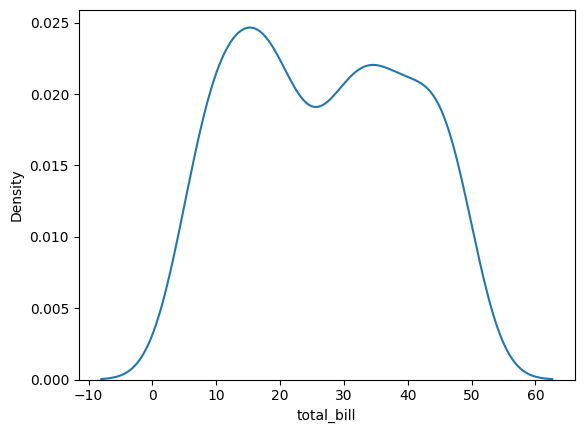

In [22]:
# kdeplot -> Kernel Density Estimation plot
# Rather than using discrete bins, a KDE plot smooths the observations with a Gaussian kernel, producing a continuous density estimate

sns.kdeplot(data=tips,x='total_bill')

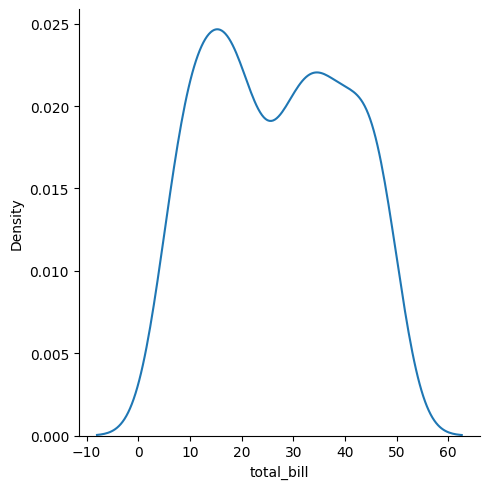

In [23]:
# using displot
sns.displot(data=tips,x='total_bill',kind='kde')


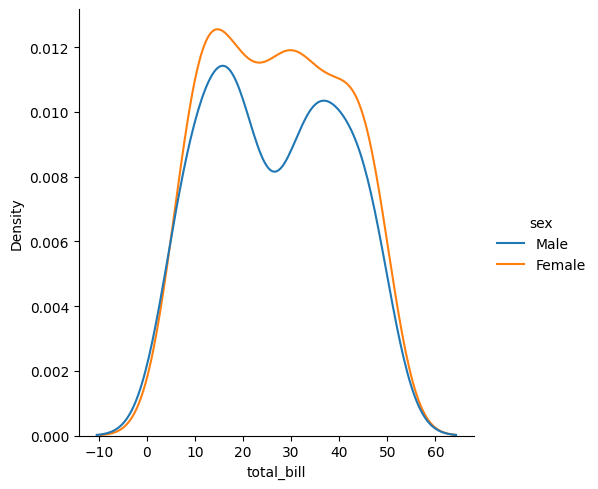

In [24]:
# hue parameter
# we can also use fill = True parameter to fill the graph
sns.displot(data=tips,x='total_bill',kind='kde',hue='sex')

<Axes: xlabel='total_bill', ylabel='Density'>

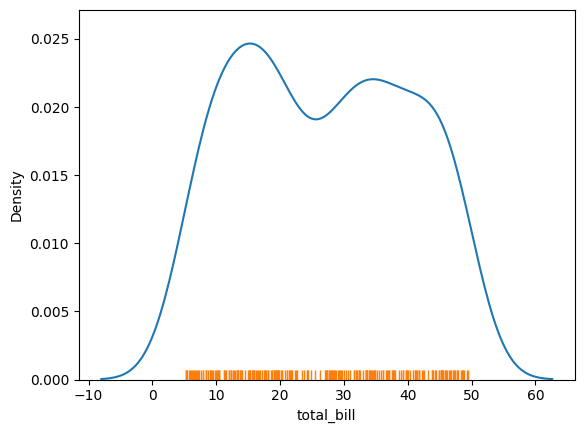

In [25]:
# Rugplot

# Plot marginal distributions by drawing ticks along the x and y axes.

# This function is intended to complement other plots by showing the location of individual observations in an unobtrusive way.

sns.kdeplot(data=tips,x='total_bill')
sns.rugplot(data=tips,x='total_bill')

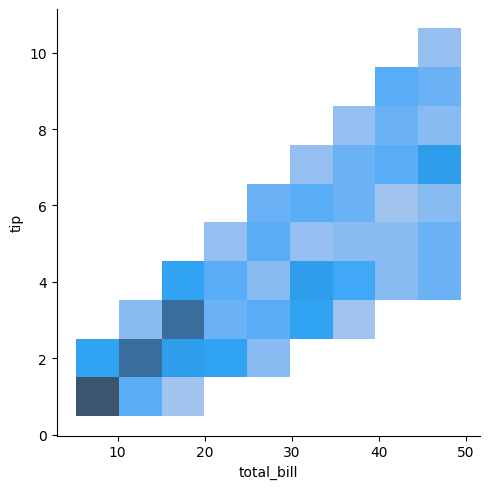

In [26]:
# Bivariate histogram
# A bivariate histogram bins the data within rectangles that tile the plot 
# and then shows the count of observations within each rectangle with the fill color

# sns.histplot(data=tips, x='total_bill', y='tip')
sns.displot(data=tips, x='total_bill', y='tip',kind='hist')

<Axes: xlabel='total_bill', ylabel='tip'>

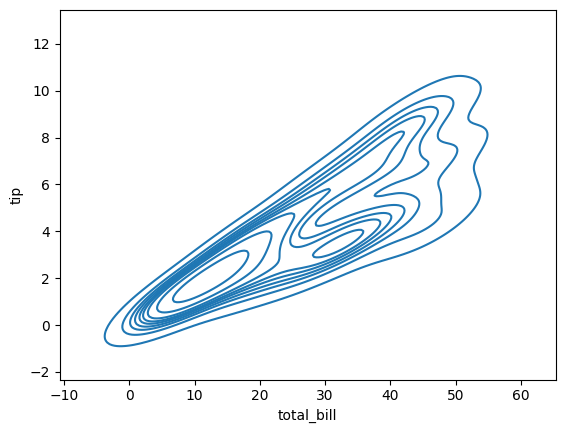

In [27]:
# Bivariate kdeplot
# A Bivariate KDE plot smoothes the x,y observations with 2D Gaussian
sns.kdeplot(data=tips, x='total_bill', y='tip')

## 3. Matrix Plot
### - Heatmap
### - Clustermap

<Axes: xlabel='year', ylabel='country'>

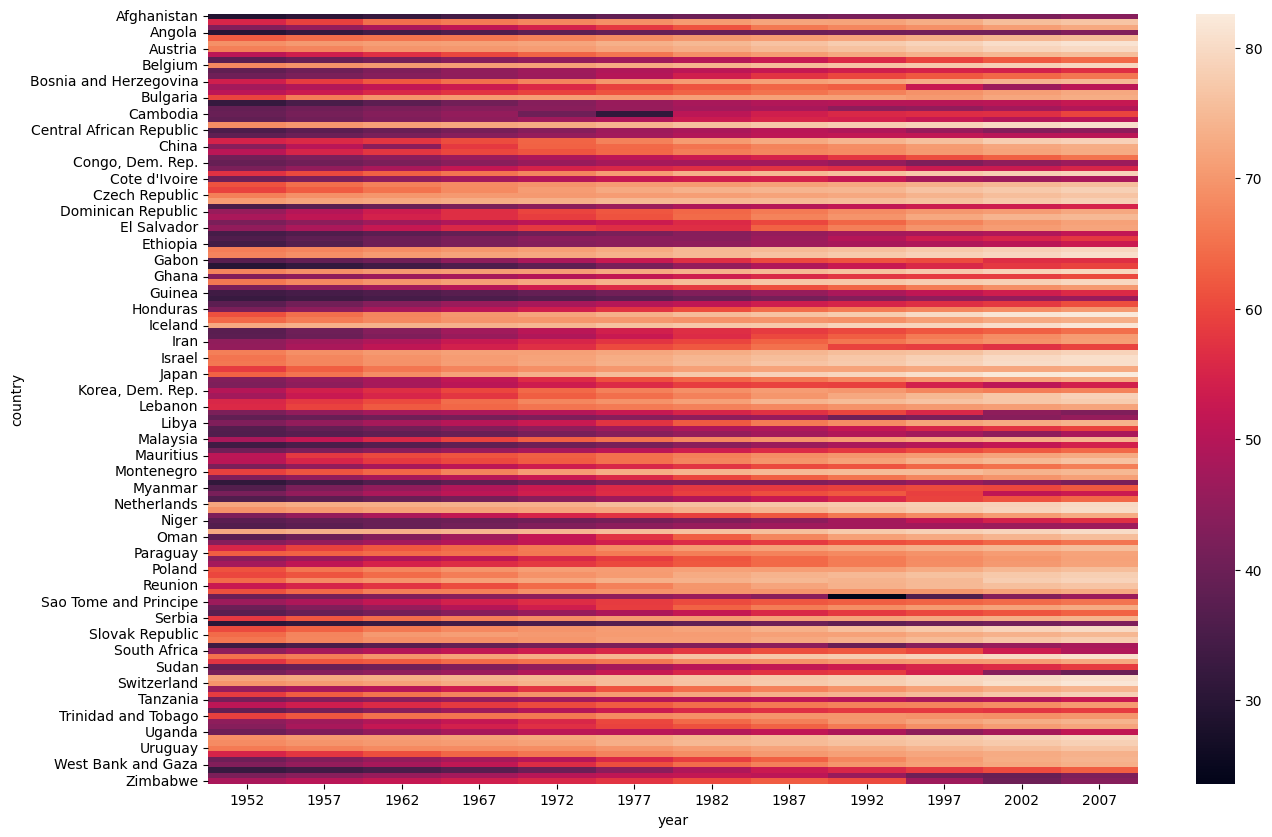

In [28]:
# Heatmap

# Plot rectangular data as a color-encoded matrix
temp_df = gap.pivot(index='country',columns='year',values='lifeExp')

# heatmap -> axes level function (no other way to form heatmap)
plt.figure(figsize=(15,10))
sns.heatmap(temp_df)

<Axes: xlabel='year', ylabel='country'>

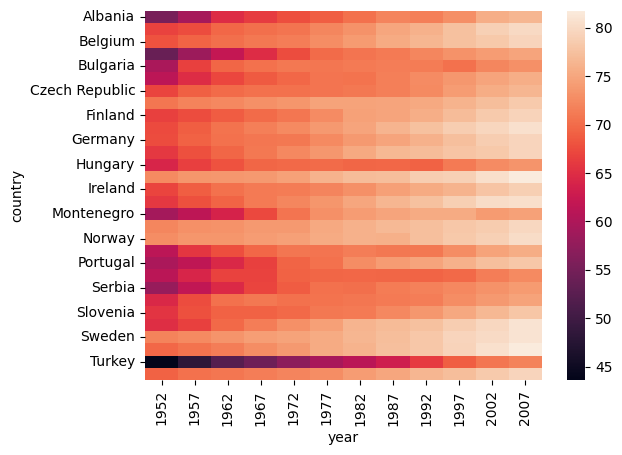

In [29]:
# for europre 
df = gap[gap['continent'] == 'Europe'].pivot(index='country',columns='year',values='lifeExp')
sns.heatmap(df)

<Axes: xlabel='year', ylabel='country'>

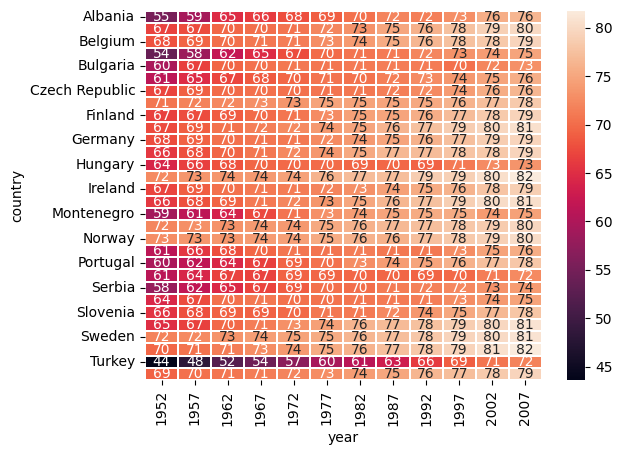

In [30]:
# annotations parameter
sns.heatmap(df,annot=True,linewidths=0.3)

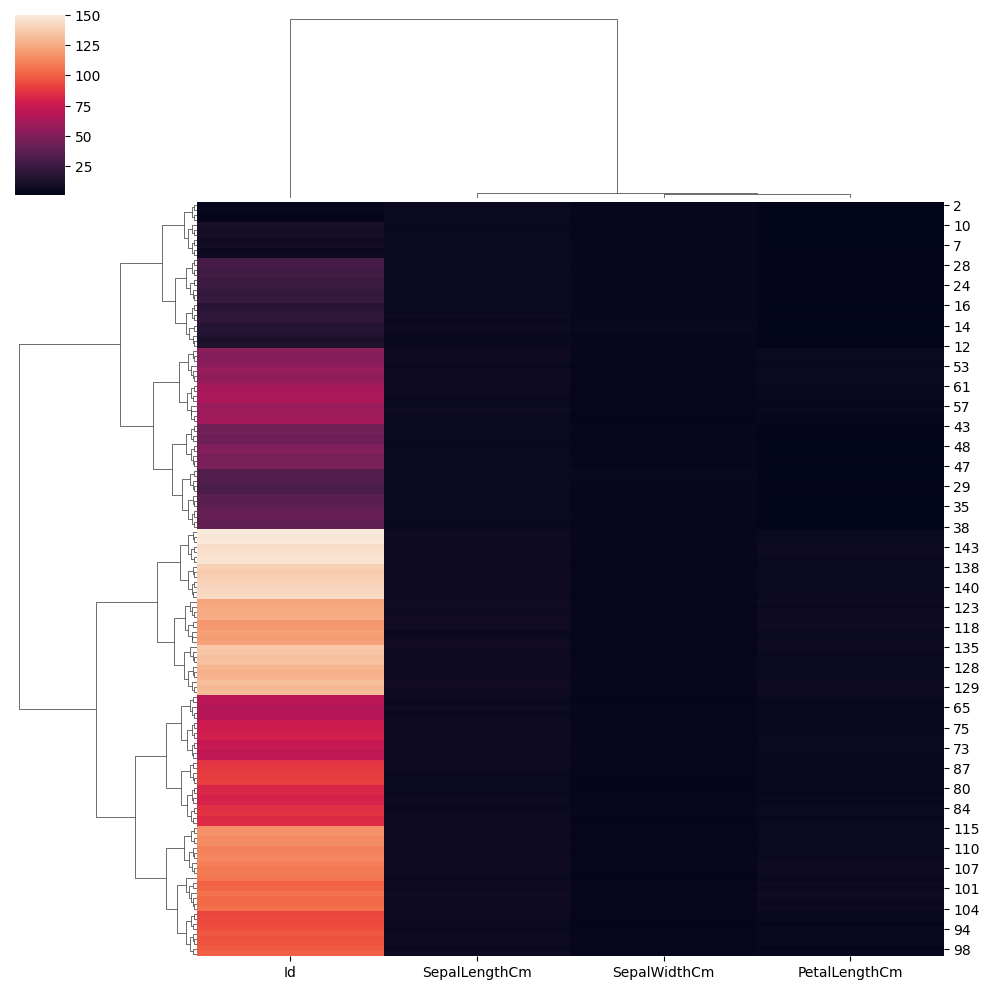

In [32]:
# Clustermap

# Plot a matrix dataset as a hierarchically-clustered heatmap.

# This function requires scipy to be available.
sns.clustermap(iris.iloc[:,[0,1,2,3]])